In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [4]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [11]:
# reload load_cluster_data
import load_cluster_data
reload (load_cluster_data)

<module 'load_cluster_data' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/load_cluster_data.py'>

In [5]:
from importlib import reload
from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [6]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., # karin had 0.65 
    "pi_prior" : 1.
}

print(hypers["eta"])

cpu
0.02


### load_cluster_data takes ~ 5 minutes for ss2 brain data.... 

In [12]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/train/'

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/train/
Finished reading in data from folder ...
['Brain_Non-Myeloid_brain_pericyte' 'Brain_Myeloid_microglial_cell'
 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_astrocyte' 'Brain_Non-Myeloid_endothelial_cell'
 'Brain_Non-Myeloid_neuron' 'Brain_Non-Myeloid_Bergmann_glial_cell'
 'Brain_Myeloid_macrophage']
5499
15824
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
1  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
2  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       10              16   
3  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       27               7   
4  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       28              12   

        

In [13]:
junction_ids_conversion.head()

,junction_id_index,junction_id,Cluster,gene_id
7023,0,10_100080130_100080856,5848,Kitl
201218,1,10_100080130_100087346,5848,Kitl
7024,2,10_100080940_100087346,5848,Kitl
1766409,3,10_100494954_100495822,5791,Cep290
1766410,4,10_100495661_100495822,5791,Cep290


In [8]:
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type
0,0,100,38.0,92,54.0,0.413043,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
1,0,102,54.0,92,38.0,0.586957,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
2,0,182,8.0,120,112.0,0.066667,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
3,0,183,112.0,120,8.0,0.933333,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
4,0,238,28.0,28,0.0,1.000000,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell


In [14]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [15]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
5499
5499


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [16]:
cell_ids_conversion.head()
# what is the breadkdown of cell types in the data 
cell_ids_conversion['cell_type'].value_counts()

Brain_Myeloid_microglial_cell                       3078
Brain_Non-Myeloid_oligodendrocyte                   1083
Brain_Non-Myeloid_endothelial_cell                   506
Brain_Non-Myeloid_astrocyte                          304
Brain_Non-Myeloid_neuron                             193
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     148
Brain_Non-Myeloid_brain_pericyte                     113
Brain_Myeloid_macrophage                              48
Brain_Non-Myeloid_Bergmann_glial_cell                 26
Name: cell_type, dtype: int64

In [17]:
# set random seed
torch.manual_seed(0)

num_trials = 10 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 50

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 15825 junctions
Got the initial ELBO ^
ELBO converged @ -209972992.0 CAVI iteration # 29 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 15825 junctions
Got the initial ELBO ^
ELBO converged @ -210261392.0 CAVI iteration # 24 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 15825 junctions
Got the initial ELBO ^
ELBO converged @ -210183840.0 CAVI iteration # 26 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 15825 junctions
Got the initial ELBO ^
ELBO converged @ -210326880.0 CAVI iteration # 19 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 15825 junctions
Got the initial ELBO ^
ELBO converged @ -210095104.0 CAVI iteration # 17 complete
Finished CAVI!
Initialize

In [18]:
running_multiple_K = False 
if running_multiple_K:
    elbos_ks = []
    for i in range(len(all_results_k)):
        print("Reporting ELBO for k = " + str(i+1))
        results = all_results_k[i]
        best = np.argmax([ g[-1][-1] for g in results ]) # best ELBO within trial
        ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
        elbos_all = np.array(elbos_all)
        print("ELBO: " + str(elbos_all[-1]))
        elbos_ks.append(elbos_all[-1])
    
    elbos_ks = pd.DataFrame(elbos_ks)
    elbos_ks["k"] = range(K)
    best_k = elbos_ks.sort_values(by=0, ascending=False).head(1)
    results = all_results_k[best_k.index[0]]
    print("The k with the highest ELBO is: " + str(best_k.index[0]+1))
    K = best_k.index[0]+1 
    print(K)

In [19]:
len(results)

10

### Consensus Clustering

In [20]:
num_trials = len(results)
N = results[0][3].shape[0]
all_iters_PHI_f = [ result[3] for result in results ]
i = 0

dfs_list = []
    
for PHI_var in all_iters_PHI_f:
    probability_tensor = PHI_var
    # Create an array with cell IDs (e.g., cell_0, cell_1, ..., cell_(N-1))
    cell_ids = np.arange(probability_tensor.shape[0])
    cell_ids = [cell_id for cell_id in cell_ids]
    # Get the cluster IDs for each cell based on the maximum probability
    cluster_ids = np.argmax(probability_tensor, axis=1)
    # Create a DataFrame with the cell_id, cluster_id, and probability columns
    df = pd.DataFrame({"cell_id": cell_ids, "cluster_id": cluster_ids})
    # Add column with iteration number
    df["iteration"] = i
    i += 1
    # Append the DataFrame to the list
    dfs_list.append(df)

# Concatenate all the DataFrames into a single DataFrame
concatenated_df = pd.concat(dfs_list, ignore_index=True)
print("Got all cells and their assignments based on PHI_f in each trial!")
# initiate list to save results for each iteration

all_iters_results = [None] * num_trials
for trial in range(num_trials):
    cell_by_cell_matrix = np.zeros((N, N))
    clusters = concatenated_df.loc[concatenated_df["iteration"] == trial, ["cell_id", "cluster_id"]]
    unique_clusters = clusters.set_index('cell_id')['cluster_id'].to_dict()
    # Fill the cell_by_cell_matrix using numpy indexing
    for cell_id, cluster_id in unique_clusters.items():
        cell_by_cell_matrix[cell_id, cell_id] = 1
        same_cluster_cells = clusters[clusters["cluster_id"] ==  cluster_id].cell_id.values
        cell_by_cell_matrix[cell_id, same_cluster_cells] = 1
    all_iters_results[trial] = cell_by_cell_matrix
# get all pairs of num_trials 
print("Got a cell by cell matrix for each trial indicating whether cells were coassigned")
# Calculate sum over matrices across all iterations to find cell-cell pairs that are MOST misassigned 
print("Getting sum of matrices across all iterations")
sum_matrices = sum(all_iters_results)
sum_matrices

Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations


array([[10.,  0.,  0., ...,  0.,  1.,  0.],
       [ 0., 10.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0., 10., ...,  1.,  0.,  1.],
       ...,
       [ 0.,  0.,  1., ..., 10.,  0.,  1.],
       [ 1.,  0.,  0., ...,  0., 10.,  1.],
       [ 0.,  0.,  1., ...,  1.,  1., 10.]])

In [23]:
# normalize by number of trials
normalized_matrix = sum_matrices / sum_matrices.max() # taking the sum_matrix and dividing by the max value in the matrix

# get distance metric 
distance_matrix = 1 - normalized_matrix
distance_matrix

# cluster distance matrix using hierarchical clustering into K clusters 
from sklearn.cluster import KMeans
# Number of clusters
num_clusters = 9

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters)
cluster_labels = kmeans.fit_predict(distance_matrix)

# Your N by K matrix
n_by_k_matrix = np.zeros((distance_matrix.shape[0], num_clusters))

# Fill the N by K matrix with cluster assignments
for i in range(num_clusters):
    n_by_k_matrix[:, i] = (cluster_labels == i).astype(int)

# sample 5200 indices from distance matrix
samp_indices = np.random.choice(cell_ids_conversion.shape[0], 5200, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_types_heatmap.cell_type.values

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

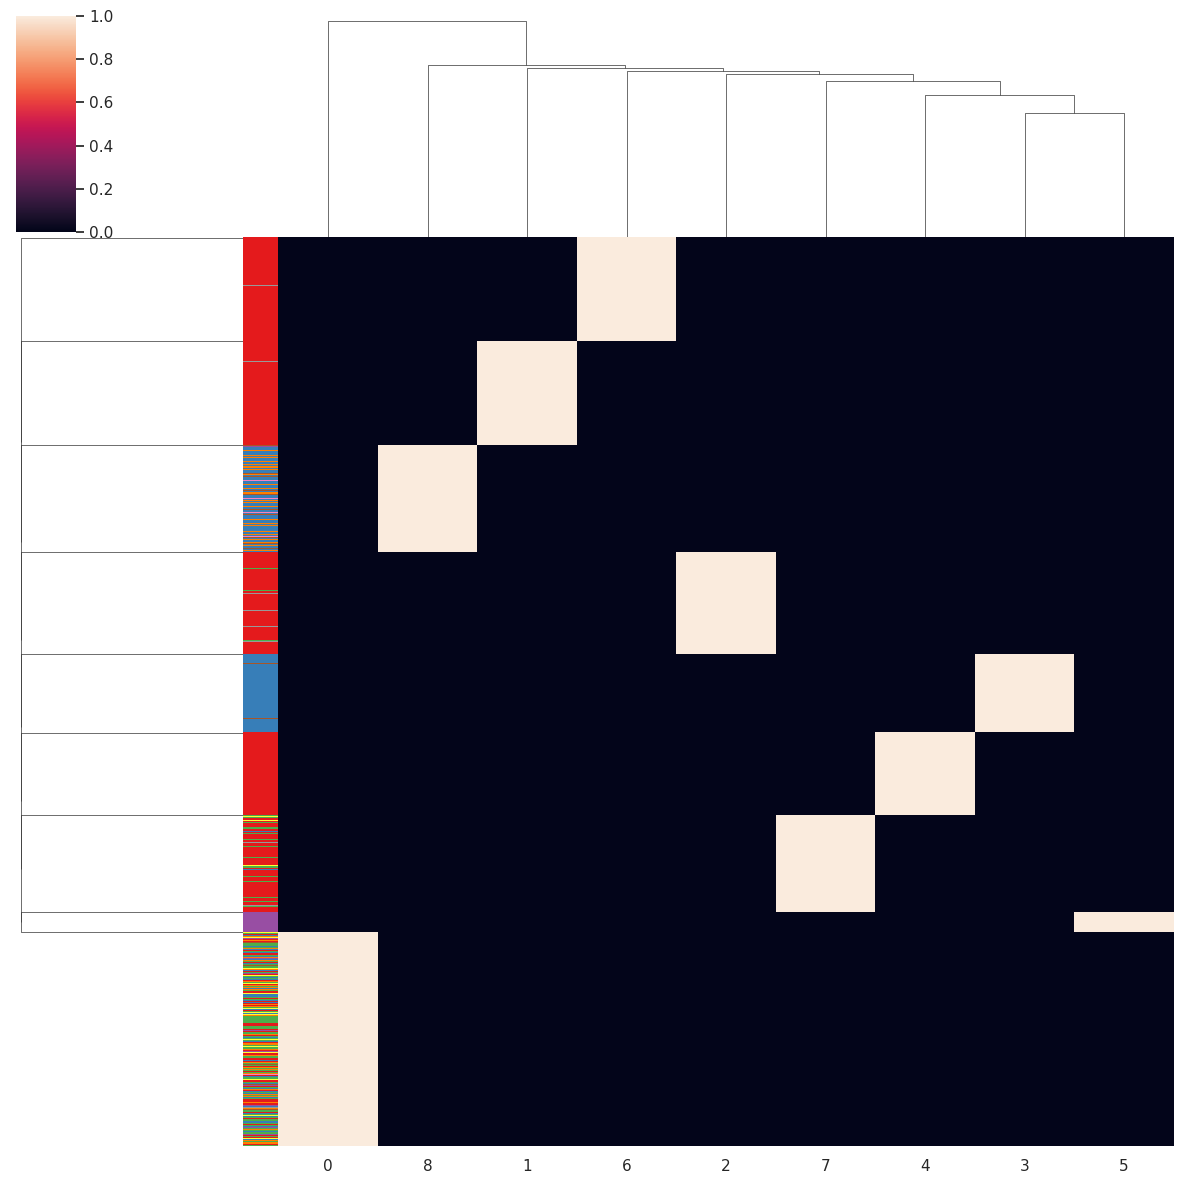

In [27]:
# draw clustermap of sampled_distance_matrix
# Create a clustermap with row colors representing cell types

clustmap = sns.clustermap(
    data=n_by_k_matrix[samp_indices,:],
    annot=False,
    fmt=".2f",
    xticklabels=True,
    yticklabels=False,
    row_colors=row_colors, 
    figsize=(12, 12))

#clustmap.ax_row_dendrogram.set_visible(False)

# Show the plot
plt.show()

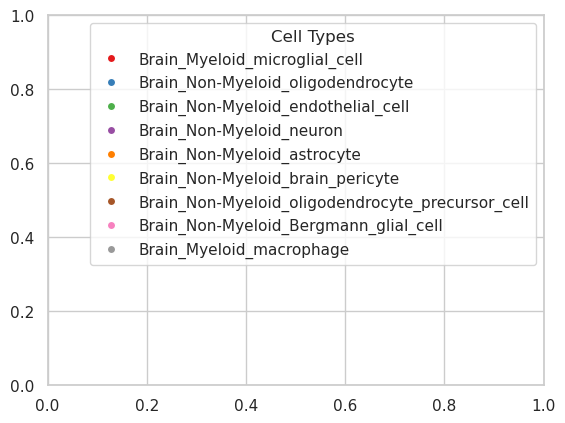

In [25]:
# Add a custom legend for row cell types
legend_labels = cell_type_colors.keys()
legend_colors = cell_type_colors.values()
custom_legend = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=6, markerfacecolor=color) for label, color in zip(legend_labels, legend_colors)]
plt.legend(handles=custom_legend, title='Cell Types')

### Evaluate the learned posteriors

The trial with the highest ELBO was 0


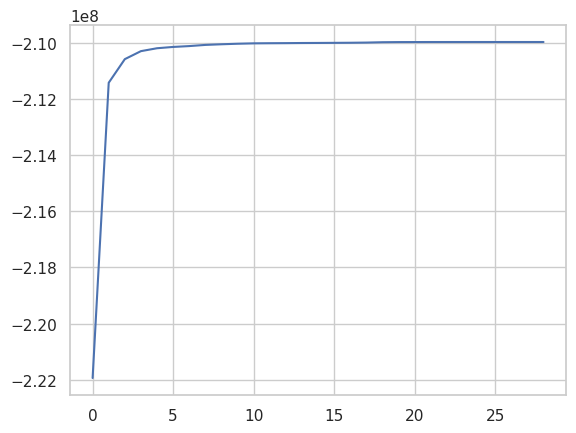

In [28]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

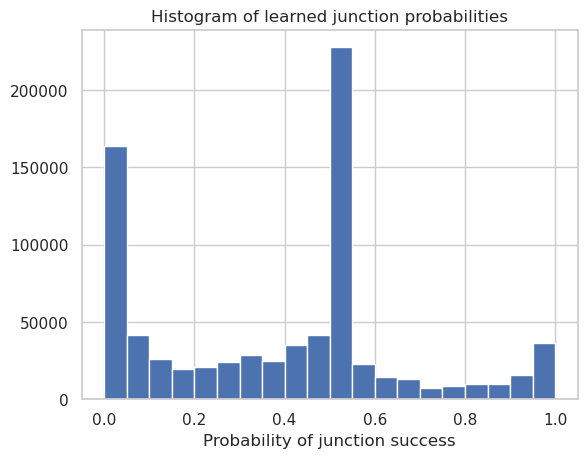

In [29]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

In [30]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

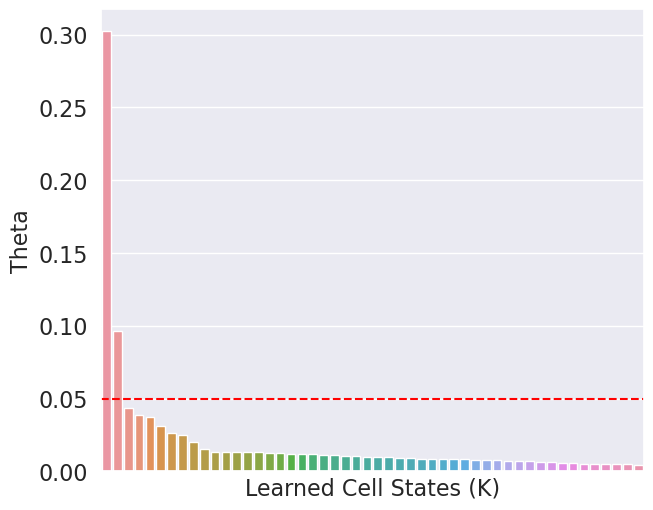

In [67]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot.head()

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())

# make barplot using sns.
plt.figure(figsize=(7, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot)
plt.axhline(0.05, ls='--', color='red')
# make Y lab say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=16)
plt.xlabel("Learned Cell States (K)", fontsize=16)
# remove xaxis ticks
plt.xticks([])
plt.yticks(fontsize=16)
plt.show()

In [32]:
# let's retain only the cell states that are used more than 1% of the time
GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.01]
GAMMA_f_plot.index.values

array([46,  1,  4, 10, 19, 29,  6, 16, 45, 32, 20, 41, 39, 38, 34,  7,  2,
       15, 21, 48, 40,  9, 37, 13, 36,  8,  0])

In [33]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,46,1,4,10,19,29,6,16,45,32,...,15,21,48,40,9,37,13,36,8,0
0,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,2.472300e-27,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5494,0.0,0.0,1.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5495,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5496,0.0,0.0,0.0,1.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5497,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_30505/3052898343.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,...,CellState_17,CellState_18,CellState_19,CellState_20,CellState_21,CellState_22,CellState_23,CellState_24,CellState_25,CellState_26
cell_type,,,,,,,,,,,,,,,,,,,,,
Brain_Myeloid_macrophage,18.000000,0.0,2.000000,0.000000,0.0,0.000000,8.000000,2.000000,0.0,0.0,...,0.000000,0.0000,1.000000,0.0,1.0,3.0,0.000000,0.000000,0.0,0.0
Brain_Myeloid_microglial_cell,1630.047852,0.0,229.992325,2.000000,16.0,133.961411,115.999985,98.998589,2.0,5.0,...,55.999989,47.9758,32.999992,8.0,16.0,26.0,22.999996,3.000000,39.0,10.0
Brain_Non-Myeloid_Bergmann_glial_cell,0.000000,0.0,0.000000,16.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0,...,0.000000,2.0000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Brain_Non-Myeloid_astrocyte,1.000000,2.0,1.000000,152.000809,2.0,2.000000,1.000000,0.000000,0.0,8.0,...,1.000000,8.0000,2.000000,1.0,2.0,1.0,4.000000,2.000000,2.0,7.0
Brain_Non-Myeloid_brain_pericyte,2.000000,0.0,0.000000,0.000000,13.0,21.000000,0.000000,12.000000,0.0,0.0,...,0.000000,0.0000,14.000000,0.0,0.0,2.0,1.000000,1.000000,0.0,4.0
Brain_Non-Myeloid_endothelial_cell,6.000000,1.0,3.000000,5.000000,168.0,9.000000,10.000000,21.000000,3.0,1.0,...,3.000000,4.0000,7.000000,1.0,2.0,22.0,4.000000,4.999999,7.0,27.0
Brain_Non-Myeloid_neuron,0.000000,1.0,0.000000,5.000000,1.0,1.000000,1.000000,0.000000,98.0,0.0,...,2.000000,1.0000,1.000000,0.0,0.0,0.0,1.000000,0.000000,0.0,2.0
Brain_Non-Myeloid_oligodendrocyte,5.000000,511.0,4.000000,16.000000,1.0,4.000000,9.039963,1.000000,8.0,62.0,...,5.000000,4.0000,4.000000,50.0,33.0,6.0,23.000000,45.000000,4.0,3.0
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.000000,14.0,0.000000,16.000000,3.0,1.000000,0.000000,1.000000,1.0,8.0,...,0.000000,0.0000,4.000000,1.0,7.0,0.0,1.000000,0.000000,4.0,3.0


In [63]:
PHI_f.shape # 27 cell states kept 

(5499, 29)

/scratch/ipykernel_30505/2520592141.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_30505/2520592141.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


{'CellState_0': ('Brain_Myeloid_microglial_cell', 0.53), 'CellState_1': ('Brain_Non-Myeloid_oligodendrocyte', 0.472), 'CellState_10': ('Brain_Myeloid_macrophage', 0.042), 'CellState_11': ('Brain_Non-Myeloid_brain_pericyte', 0.142), 'CellState_12': ('Brain_Myeloid_macrophage', 0.021), 'CellState_13': ('Brain_Non-Myeloid_astrocyte', 0.026), 'CellState_14': ('Brain_Non-Myeloid_endothelial_cell', 0.022), 'CellState_15': ('Brain_Myeloid_macrophage', 0.042), 'CellState_16': ('Brain_Non-Myeloid_astrocyte', 0.082), 'CellState_17': ('Brain_Myeloid_microglial_cell', 0.018), 'CellState_18': ('Brain_Non-Myeloid_Bergmann_glial_cell', 0.077), 'CellState_19': ('Brain_Non-Myeloid_brain_pericyte', 0.124), 'CellState_2': ('Brain_Myeloid_microglial_cell', 0.075), 'CellState_20': ('Brain_Non-Myeloid_oligodendrocyte', 0.046), 'CellState_21': ('Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 0.047), 'CellState_22': ('Brain_Myeloid_macrophage', 0.062), 'CellState_23': ('Brain_Non-Myeloid_oligodendrocyte',

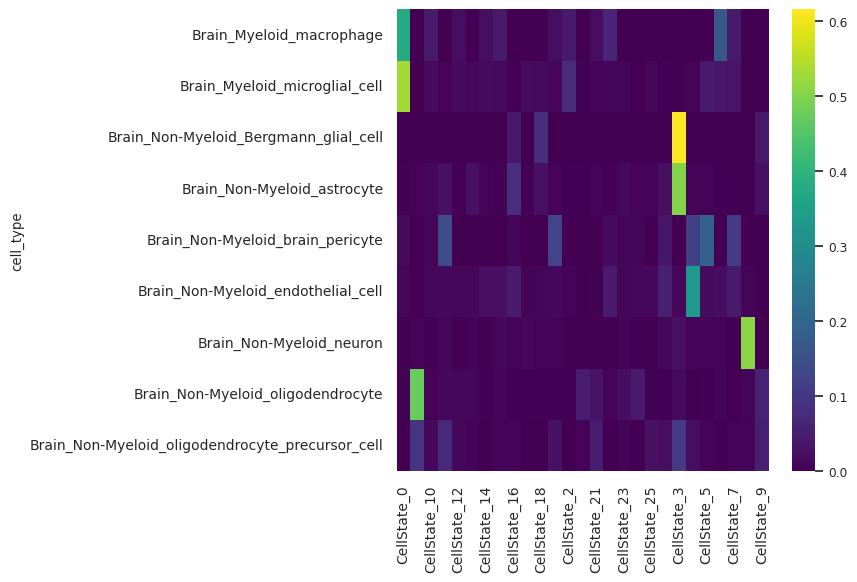

In [66]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(6, 6))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
sns.heatmap(sum_prop, annot=False, fmt=".2f", cmap='viridis')

# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

In [47]:
sum_prop

,CellState_0,CellState_1,CellState_10,CellState_11,CellState_12,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,...,CellState_24,CellState_25,CellState_26,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9
cell_type,,,,,,,,,,,,,,,,,,,,,
Brain_Myeloid_macrophage,0.375000,0.000000,0.041667,1.229056e-44,0.020833,0.000000,0.020833,0.041667,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.041667,0.000000,0.000000
Brain_Myeloid_microglial_cell,0.529580,0.000000,0.017544,4.873294e-03,0.016894,0.013970,0.017544,0.015595,0.004556,0.018194,...,0.000975,0.012671,0.003249,0.000650,0.005198,0.043522,0.037687,0.032163,0.000650,0.001624
Brain_Non-Myeloid_Bergmann_glial_cell,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.038462,0.000000,...,0.000000,0.000000,0.000000,0.615385,0.000000,0.000000,0.000000,0.000000,0.000000,0.038462
Brain_Non-Myeloid_astrocyte,0.003289,0.006579,0.013158,2.631579e-02,0.003289,0.026316,0.006579,0.003289,0.082234,0.003289,...,0.006579,0.006579,0.023026,0.500003,0.006579,0.006579,0.003289,0.000000,0.000000,0.026316
Brain_Non-Myeloid_brain_pericyte,0.017699,0.000000,0.008850,1.415929e-01,0.000000,0.000000,0.000000,0.000000,0.008850,0.000000,...,0.008850,0.000000,0.035398,0.000000,0.115044,0.185841,0.000000,0.106195,0.000000,0.000000
Brain_Non-Myeloid_endothelial_cell,0.011858,0.001976,0.009881,1.383399e-02,0.009881,0.011858,0.021739,0.021739,0.045455,0.005929,...,0.009881,0.013834,0.053360,0.009881,0.332016,0.017787,0.019763,0.041502,0.005929,0.001976
Brain_Non-Myeloid_neuron,0.000000,0.005181,0.000000,1.036269e-02,0.000000,0.005181,0.000000,0.010363,0.005181,0.010363,...,0.000000,0.000000,0.010363,0.025907,0.005181,0.005181,0.005181,0.000000,0.507772,0.000000
Brain_Non-Myeloid_oligodendrocyte,0.004617,0.471837,0.006464,1.385042e-02,0.010157,0.012004,0.003693,0.005540,0.002770,0.004617,...,0.041551,0.003693,0.002770,0.014774,0.000923,0.003693,0.008347,0.000923,0.007387,0.057248
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.000000,0.094595,0.013514,6.756757e-02,0.013514,0.006757,0.000000,0.006757,0.006757,0.000000,...,0.000000,0.027027,0.020270,0.108108,0.020270,0.006757,0.000000,0.006757,0.006757,0.054054


## Do differential junction analysis 

In [37]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [38]:
def plot_juncObsUsage(junc_index):

    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]

    # get data for just junc_index 
    junc_dat=final_data[final_data.junction_id_index==junc_index]
    print(junc_dat.cell_type.value_counts())

    # make violin plot for junc_dat junction usage ratio coloured by cell_type and rotate plot 90 degrees
    plot = ggplot(junc_dat, aes(x='cell_type', y='juncratio', fill="cell_type")) + geom_violin() + geom_point() + plotnine.labels.ggtitle(junc_id) + plotnine.coords.coord_flip() 

    # add number of cells in each cell_type to plot 
    print(plot)

def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]
    
    # get data for just junc_index 
    junc_dat=juncs_probs_df[juncs_probs_df.junction_id_index==junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [39]:
# calculate sd deviation for each junction for cell states 0 to 19 
juncs_probs_df["sd"] = juncs_probs_df.iloc[:,0:K].std(axis=1)

In [41]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test=scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).junction_id_index.values

In [78]:
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index").sort_values(by="score", ascending=False).head(10)

In [106]:
def quick_junc_plot(junc, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["junction_id_index"] == junc]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Junction:" + str(junc) + " Gene: " + simple_data_junc["gene_id"].values[0])
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [101]:
def quick_clust_plot(clust, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    # set figure size to be 6 by 7 
    plt.figure(figsize=(6, 7))
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Cluster:" + str(clust) + " Gene: " + simple_data_junc["gene_id"].values[0])
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [99]:
simple_data = final_data[["cell_id_index", "cell_type", "junction_id_index", "junc_count", "cluster_count"]]
simple_data = simple_data.merge(junction_ids_conversion, on="junction_id_index")
simple_data["junc_ratio"] = simple_data["junc_count"] / simple_data["cluster_count"]
simple_data.head()

,cell_id_index,cell_type,junction_id_index,junc_count,cluster_count,junction_id,Cluster,gene_id,junc_ratio
0,0,Brain_Myeloid_microglial_cell,100,38.0,92,10_127063759_127064219,5790,Cdk4,0.413043
1,2,Brain_Non-Myeloid_oligodendrocyte,100,30.0,70,10_127063759_127064219,5790,Cdk4,0.428571
2,5,Brain_Myeloid_microglial_cell,100,1.0,2,10_127063759_127064219,5790,Cdk4,0.500000
3,11,Brain_Non-Myeloid_endothelial_cell,100,5.0,16,10_127063759_127064219,5790,Cdk4,0.312500
4,15,Brain_Non-Myeloid_endothelial_cell,100,16.0,39,10_127063759_127064219,5790,Cdk4,0.410256


In [79]:
scores_all_juncs_df

,score,junction_id_index,junction_id,Cluster,gene_id
4642,29658.679688,4642,16_85030365_85056323,8680,App
4644,8023.125000,4644,16_85043743_85056323,8680,App
10055,6742.144531,10055,4_139287832_139291002,2028,Capzb
4638,6040.007812,4638,16_84965770_84978063,8674,App
4640,5751.984375,4640,16_85030365_85040250,8680,App
15005,5624.250000,15005,9_67023441_67031028,5707,Tpm1
4643,5251.585938,4643,16_85040307_85043575,8680,App
15398,2987.597656,15398,X_140542156_140598127,10235,Tsc22d3
15397,2987.597656,15397,X_140542156_140542845,10235,Tsc22d3
13116,2844.431641,13116,7_4133738_4133865,4085,Ttyh1


Brain_Non-Myeloid_oligodendrocyte                   964
Brain_Myeloid_microglial_cell                       832
Brain_Non-Myeloid_endothelial_cell                  409
Brain_Non-Myeloid_neuron                            137
Brain_Non-Myeloid_oligodendrocyte_precursor_cell    123
Brain_Non-Myeloid_brain_pericyte                     66
Brain_Non-Myeloid_astrocyte                          46
Brain_Myeloid_macrophage                             25
Brain_Non-Myeloid_Bergmann_glial_cell                 7
Name: cell_type, dtype: int64


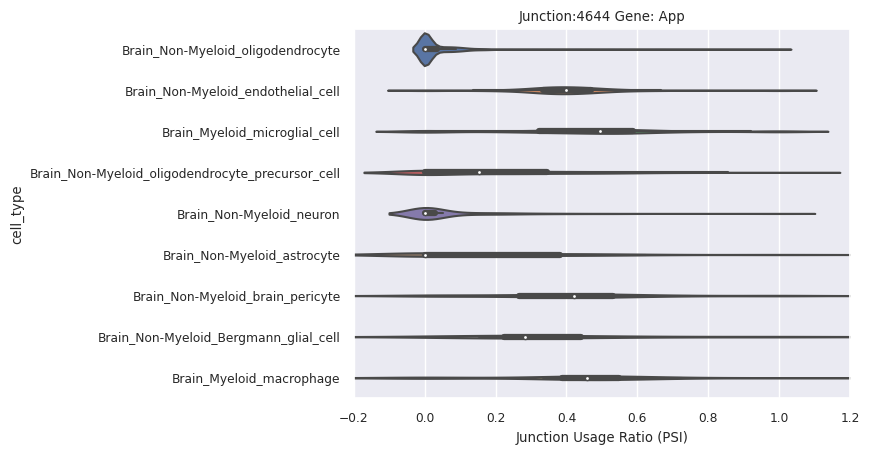

In [108]:
quick_junc_plot(4644, simple_data, True)

Brain_Non-Myeloid_oligodendrocyte                   964
Brain_Myeloid_microglial_cell                       832
Brain_Non-Myeloid_endothelial_cell                  409
Brain_Non-Myeloid_neuron                            137
Brain_Non-Myeloid_oligodendrocyte_precursor_cell    123
Brain_Non-Myeloid_brain_pericyte                     66
Brain_Non-Myeloid_astrocyte                          46
Brain_Myeloid_macrophage                             25
Brain_Non-Myeloid_Bergmann_glial_cell                 7
Name: cell_type, dtype: int64


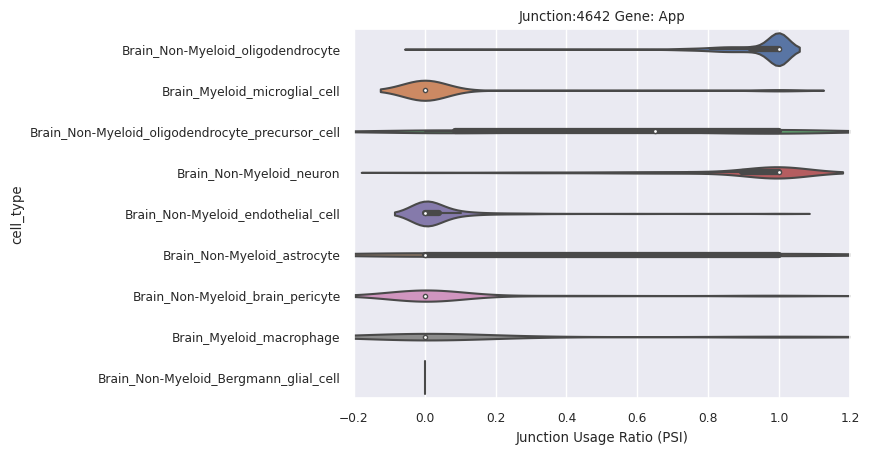

In [107]:
quick_junc_plot(4642, simple_data, True)

In [ ]:
# make a version of the plot that shows that learned junction proportions across cell states 

def quick_posterior_junc_plot(junc, ALPHAs, PIs):
    junc_a = ALPHAs[junc, ]
    junc_b = PIs[junc, ]
    plt.figure(figsize=(6, 7))
    # make violin plot with jitter
    sns.violinplot(data = junc_a / (junc_a + junc_b))
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title
    plt.title("Junction:" + str(junc))
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Posterior PSI via Leaflet")

quick_posterior_junc_plot(junc, ALPHA_f, PI_f)

Brain_Non-Myeloid_oligodendrocyte                   4820
Brain_Myeloid_microglial_cell                       4160
Brain_Non-Myeloid_endothelial_cell                  2045
Brain_Non-Myeloid_neuron                             685
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     615
Brain_Non-Myeloid_brain_pericyte                     330
Brain_Non-Myeloid_astrocyte                          230
Brain_Myeloid_macrophage                             125
Brain_Non-Myeloid_Bergmann_glial_cell                 35
Name: cell_type, dtype: int64


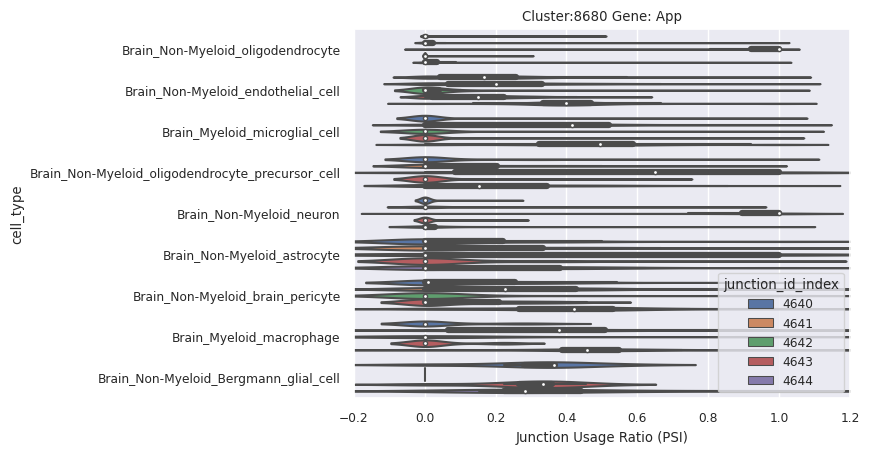

In [103]:
quick_clust_plot(8680, simple_data, True)

In [43]:
# save cell assignments to file for downstream analysis
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/'

# BBmixture model cell assignments
output_file = os.path.join(output_dir, 'Leaflet_BBmixture.csv')
PHI_f.to_csv(output_file, index=True, header=True)
print('Saved Leaflet latent cell states to {}'.format(output_file))

Saved Leaflet latent cell states to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv


In [45]:
# Let's find the junctions that are the most differentially spliced between microglia and astrocytes 
scores_all_juncs = []
cellstate1 = 0
cellstate2 = 1

for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [cellstate1,cellstate2]]
    b = PI_f[junc_index, [cellstate1,cellstate2]]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test=scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).junction_id_index.values

## Evaluate likelihood on validation set to determine best K

In [73]:
# validation data 
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/validation/'

val_data, val_coo_counts_sparse, val_coo_cluster_sparse, val_cell_ids_conversion, val_junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes")
cell_index_tensor_val, junc_index_tensor_val, my_data_val = make_torch_data(val_data, **float_type)

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/validation/
Finished reading in data from folder ...
['Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_Bergmann_glial_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Myeloid_microglial_cell'
 'Brain_Non-Myeloid_brain_pericyte' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_astrocyte' 'Brain_Non-Myeloid_neuron'
 'Brain_Myeloid_macrophage']
1571
15824
                                             cell_id  Cluster  Cluster_Counts  \
0  A10-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_oli...        2              20   
1  A10-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_oli...       10              15   
2  A10-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_oli...       25              47   
3  A10-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_oli...       44             209   
4  A10-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_oli...       44             209   

   

In [ ]:
import betabinomo_mix_singlecells
reload(betabinomo_mix_singlecells)

In [ ]:
# set random seed
torch.manual_seed(0)

num_trials = 1 # should also be an argument that gets fed in
num_iters = 40 # should also be an argument that gets fed in
K = 12

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()
all_results_k = []
all_ll_k = []

for k in range(K):
    k = k + 1
    print(f"Running with {k} cell states")
    results = [ betabinomo_mix_singlecells.calculate_CAVI(k, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]
    
    all_results_k.append(results)
    ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[0]
    juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
    juncs_probs_df = pd.DataFrame(juncs_probs.numpy())
    # rename columns to be "state_0", "state_1", etc.
    juncs_probs_df.columns = ["state_" + str(i) for i in range(juncs_probs_df.shape[1])]
    juncs_probs_df["junction_id_index"] = juncs_probs_df.index

    # merge with val_data 
    val_data_run = val_data.merge(juncs_probs_df, on="junction_id_index")
    theta = GAMMA_f / GAMMA_f.sum()
    theta = theta.cpu().numpy()

    # evaluate predictive log likelihood on validation set 
    print("Calculating predictive log likelihood on validation set")
    ll = betabinomo_mix_singlecells.calculate_predictive_lik(theta, val_data_run)
    all_ll_k.append(ll)
    print(f"Predictive log likelihood on validation set is {ll}")

# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

In [ ]:
(all_ll_k == np.max(all_ll_k))

In [ ]:
all_ks = pd.DataFrame(np.array(all_ll_k))
all_ks["k"] = all_ks.index
all_ks.columns = ["ll", "k"]
all_ks.sort_values("ll", ascending=False)

In [ ]:
import matplotlib.pyplot as plt

# Given data
data = [
    (10, -3.759537e+07),
    (11, -3.792445e+07),
    (9, -3.812037e+07),
    (7, -3.837194e+07),
    (8, -3.856408e+07),
    (6, -3.934490e+07),
    (5, -3.983091e+07),
    (4, -4.040786e+07),
    (2, -4.199341e+07),
    (3, -4.218076e+07),
    (1, -4.448278e+07),
    (0, -4.958535e+07)
]

# Unpack data into separate lists for x and y values
x_values, y_values = zip(*data)

# Create a bar plot
plt.bar(x_values, y_values, color='blue')

# Add labels and title
plt.xlabel('k', fontsize=14)
plt.ylabel('Log Likelihood (ll)', fontsize=14)
plt.title('Log Likelihood vs k', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Show the plot
plt.show()
